In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import numpy as np
import glob
import os
import statsmodels.api as sm

Pasamos por todos los classifications para ver la distribucion de categorias estructurales de SQANTI

In [53]:
# Vamos a ver primero como se distribuyen a nivel de categorias estructurales,
filas = []

for i in glob.glob("../inputs_2/*"):
    muestra = os.path.basename(i)
    TS = muestra.split("_")[0]
    RIN = muestra.split("_")[2]
    RIN_TS = RIN + "_" + TS
    
    df = pd.read_csv(i,sep="\t",low_memory=False)
    
    for j in df["structural_category"].unique():
        porc = len(df[df["structural_category"] == j])/len(df)
        filas.append([j,porc,RIN_TS])
columnas = ["structural_category","Porcentaje","RIN_TS"]
StrCats = pd.DataFrame(filas)
StrCats.columns = columnas
StrCats.head()


,structural_category,Porcentaje,RIN_TS
0,incomplete-splice_match,0.352297,7.7_TS10
1,novel_in_catalog,0.016772,7.7_TS10
2,genic,0.019440,7.7_TS10
3,full-splice_match,0.528142,7.7_TS10
4,novel_not_in_catalog,0.052227,7.7_TS10


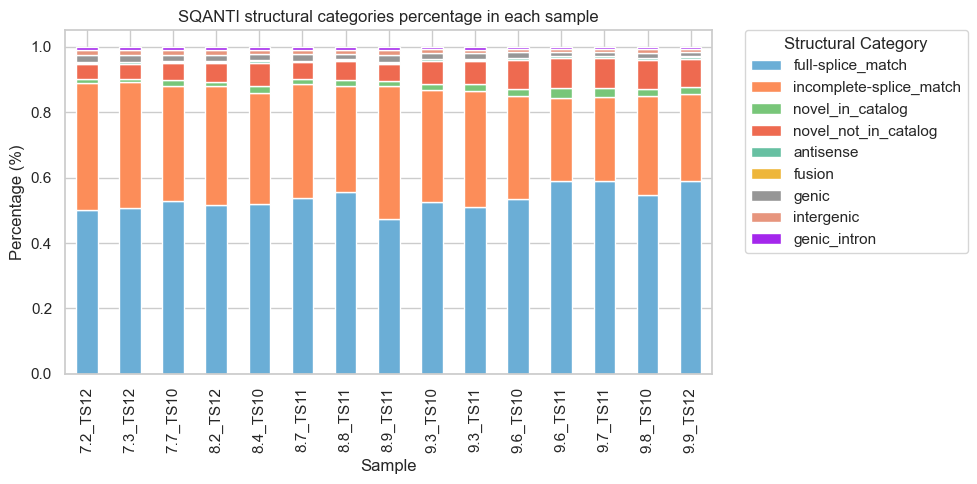

In [54]:
StrCats["Porcentaje"] = StrCats["Porcentaje"].astype(float)
colores = {
    "full-splice_match": "#6baed6",
    "incomplete-splice_match": "#fc8d59",
    "novel_in_catalog": "#78c679",
    "novel_not_in_catalog": "#ee6a50",
    "genic_intron" :"#a427ec",
    "genic": "#969696",
    "intergenic":"#e7957d",
    "antisense" :"#67c0a2",
    "fusion":"#eeb63a"
}
orden = ["full-splice_match","incomplete-splice_match","novel_in_catalog","novel_not_in_catalog","antisense","fusion","genic","intergenic","genic_intron"]
tabla = StrCats.pivot_table(
    index="RIN_TS",
    columns="structural_category",
    values="Porcentaje",
    aggfunc="sum"
).fillna(0)
tabla = tabla[orden]
ax = tabla.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    color=[colores.get(col, "#999999") for col in tabla.columns]
)
ax.legend(
    title="Structural Category",
    bbox_to_anchor=(1.05, 1),  # fuera a la derecha
    loc="upper left",
    borderaxespad=0
)
plt.title("SQANTI structural categories percentage in each sample")
plt.ylabel("Percentage (%)")
plt.xlabel("Sample")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Podemos enfocarnos solo en los FSMs, los ISMs y los novel

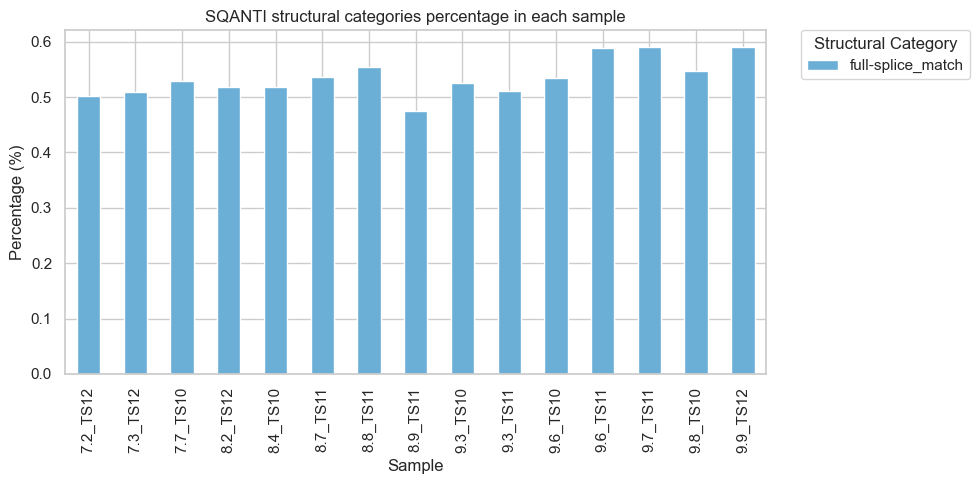

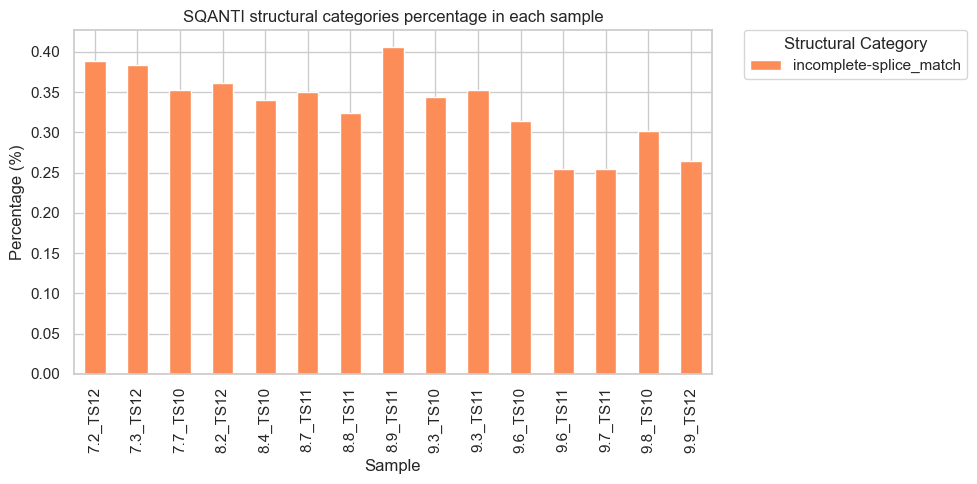

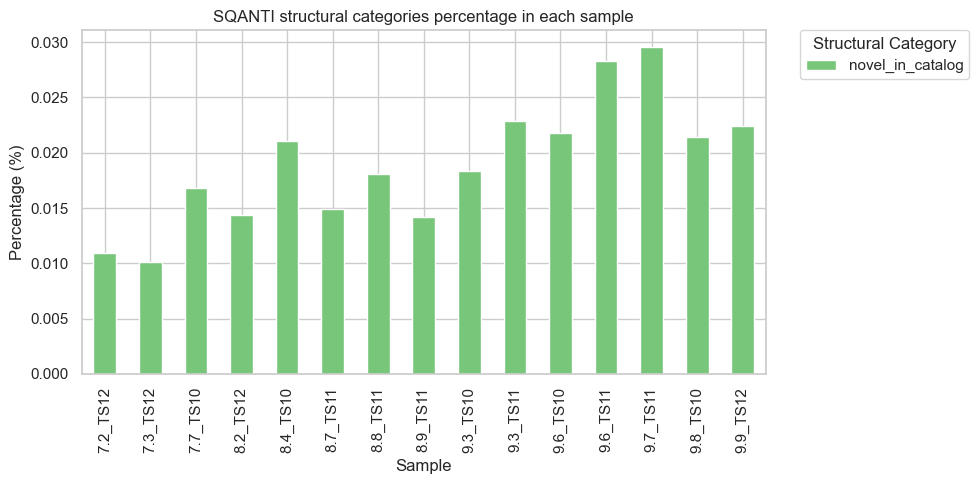

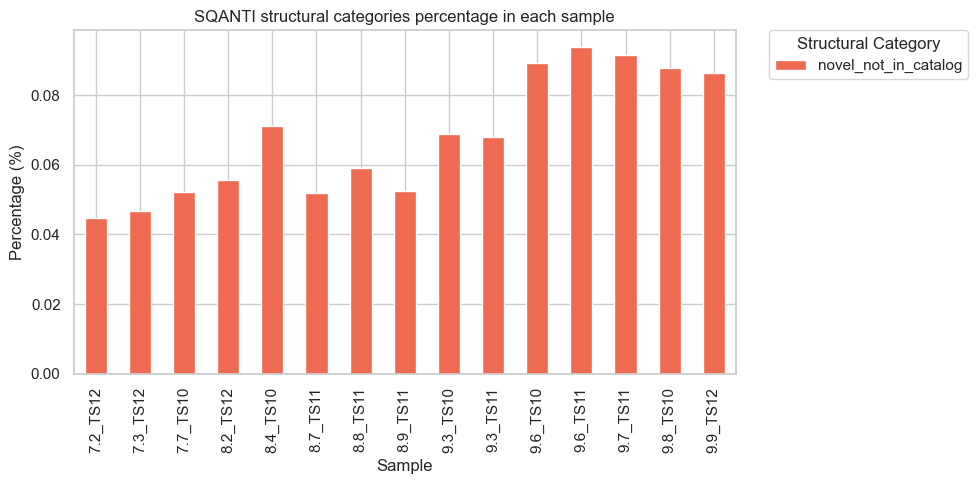

In [55]:
for i in range(4):
    ax = tabla.iloc[0:,i].plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5),
        color=[colores.get(tabla.columns[i], "#999999") for col in tabla.columns]
    )
    ax.legend(
        title="Structural Category",
        bbox_to_anchor=(1.05, 1),  # fuera a la derecha
        loc="upper left",
        borderaxespad=0
    )
    plt.title("SQANTI structural categories percentage in each sample")
    plt.ylabel("Percentage (%)")
    plt.xlabel("Sample")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [56]:
def calc_pendiente(grupo,col):
    x = grupo["RIN"]
    y = grupo[col]
    w = grupo["counts"]

    X = sm.add_constant(x)  # añade el intercepto
    modelo = sm.WLS(y, X, weights=w).fit()

    return modelo.params["RIN"]

Ahora podemos fijarnos en la ifnormación de los transcritos que hemos sacado

In [57]:
mt = pd.read_csv("../megatabla_7.tsv", sep="\t")

In [58]:

# Número total de grupos TS-RIN
n_grupos = mt[['TS', 'RIN']].drop_duplicates().shape[0]

# Número de grupos distintos en los que aparece cada transcritp
grupos_por_transcript = (
    mt.groupby('associated_transcript')[['TS', 'RIN']]
      .apply(lambda x: x.drop_duplicates().shape[0])
)

# Claves presentes en todos los grupos
transcripts_comunes = grupos_por_transcript[grupos_por_transcript == n_grupos].index.tolist()
print(len(transcripts_comunes))


5076


Un primer analisis puede ser exploratorio para ver como correlacionan entre si las muestras

In [59]:


# Número de grupos distintos en los que aparece cada clave
grupos_por_clave = (
    mt.groupby('clave')[['TS', 'RIN']]
      .apply(lambda x: x.drop_duplicates().shape[0])
)

# Claves presentes en todos los grupos
claves_comunes = grupos_por_clave[grupos_por_clave == n_grupos].index.tolist()

print(len(claves_comunes))

5574


In [60]:
# Sacamos solo las filas que están para todas las muestras
mt['sample'] = (
    mt['TS'].astype(str) + '_' +
    mt['RIN'].astype(str) + '_' 
    # + mt["seqbatch"].astype(str) + '_' + 
    #mt["time"].astype(str)
)
matriz = mt.pivot_table(
    index='clave',
    columns='sample',
    values='counts_transcript'
)
matriz_cpm = mt.pivot_table(
    index='clave',
    columns='sample',
    values='CPM_transcript'
)
# Nos quitamos los 0s
matriz = matriz.fillna(0)
matriz_cpm = matriz_cpm.fillna(0)
# Transformacion log1p
matriz = np.log1p(matriz)
matriz_cpm = np.log1p(matriz_cpm)
# Sacamos las correlaciones
corr = matriz.corr()
corr_cpm = matriz_cpm.corr()
print(corr.mean().mean())
print(corr_cpm.mean().mean())


0.6754513440740659
0.7123565569724495


c:\Users\Andres\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\1568956960.py:16: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Andres\\Desktop\\JAE_ICU\\nanopore_RNA_degradation\\cosas_mias - dRNA\\OFICIAL\\notebooks\\figuras_tfm\\heatmap_samples_counts.png'

<Figure size 1000x1600 with 0 Axes>

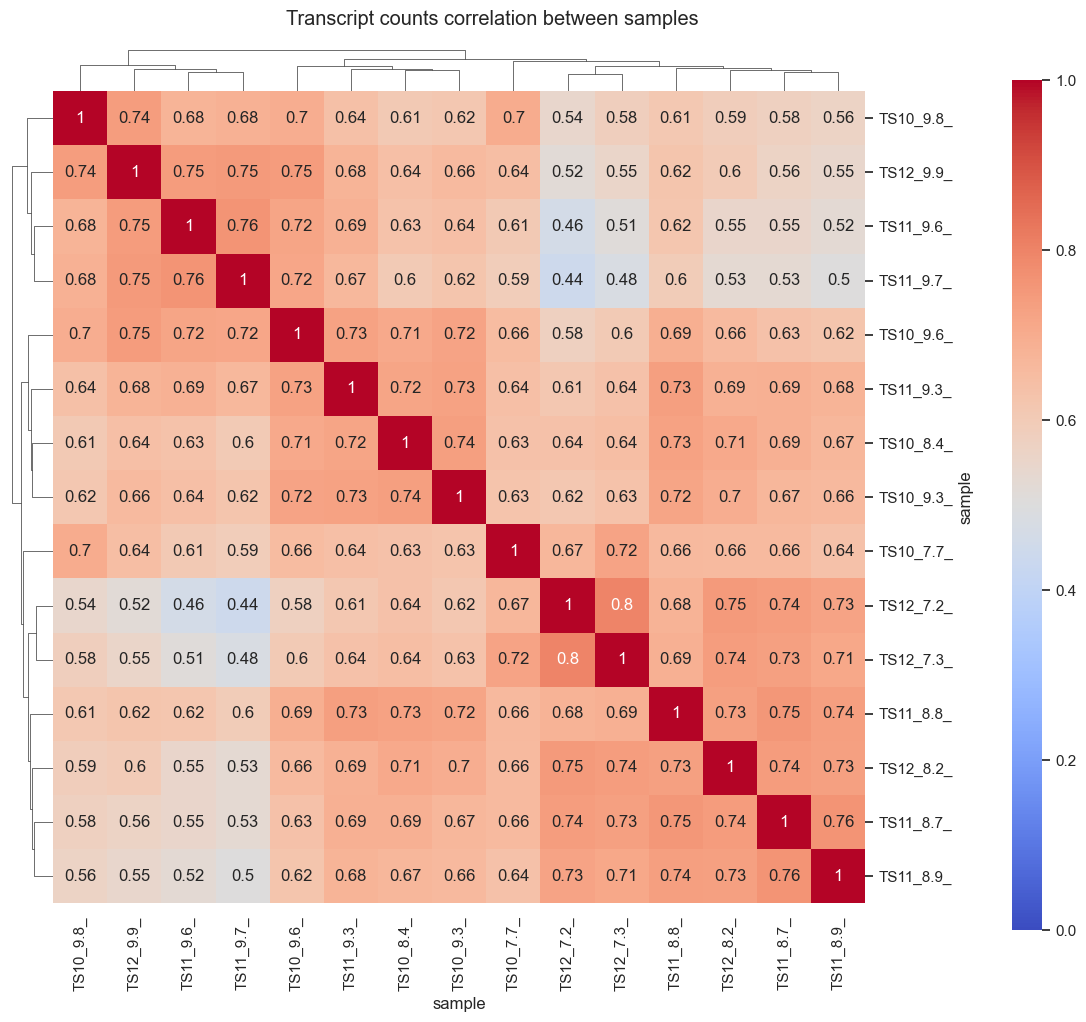

In [61]:
# Heatmap
plt.figure(figsize=(10, 16))
g = sns.clustermap(
    corr,
    annot=True,
    cmap='coolwarm',
    vmin=0,
    vmax=corr.max().max(),
    #center=0,
    square=True,
    cbar_pos=(1.02, 0.1, 0.03, 0.85),
    dendrogram_ratio=(0.05, 0.05) 
)

g.fig.suptitle('Transcript counts correlation between samples', y=1.02)
plt.tight_layout()
g.savefig("figuras_tfm/heatmap_samples_counts.png", bbox_inches="tight")
plt.show()

c:\Users\Andres\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
C:\Users\Andres\AppData\Local\Temp\ipykernel_12976\3308572392.py:16: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


<Figure size 1000x1600 with 0 Axes>

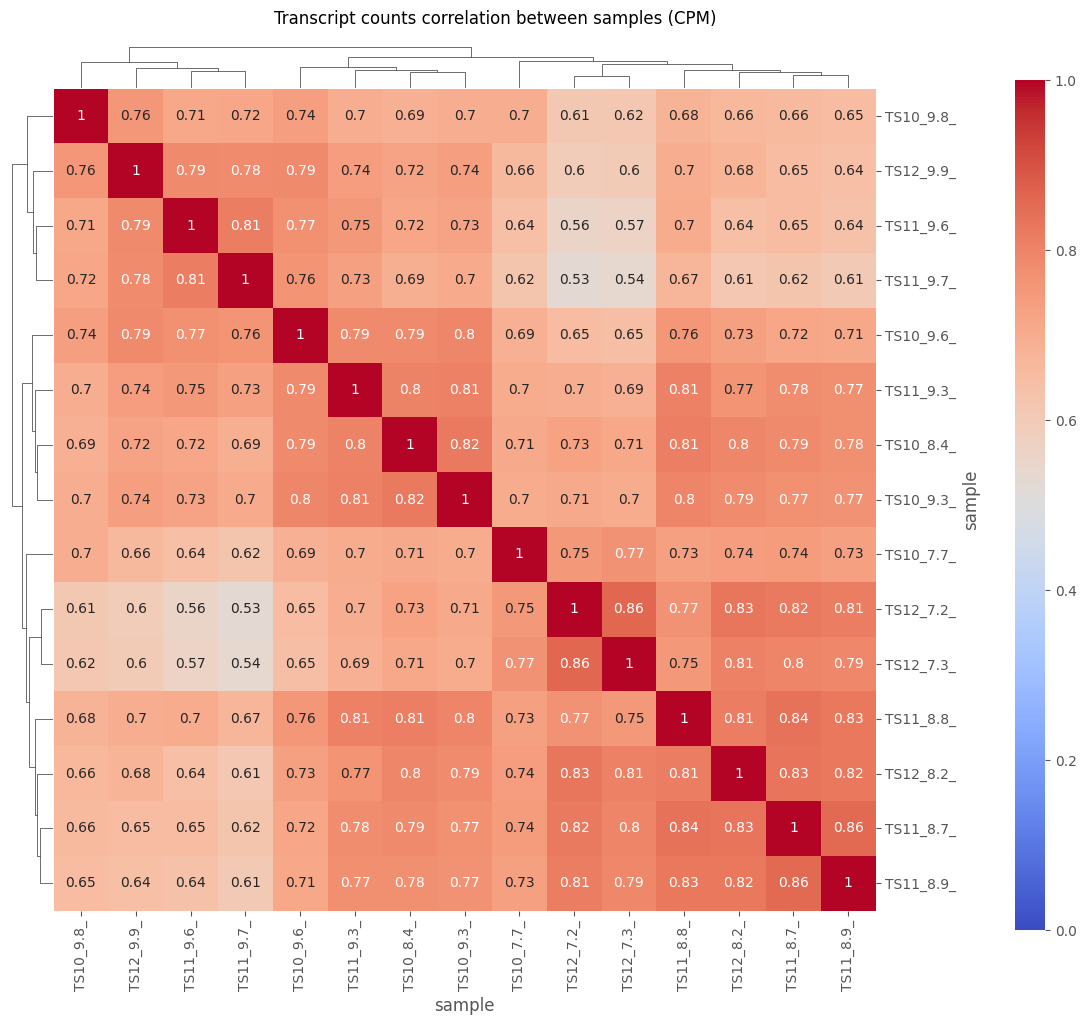

In [ ]:
# Heatmap
plt.figure(figsize=(10, 16))
g = sns.clustermap(
    corr_cpm,
    annot=True,
    cmap='coolwarm',
    vmin=0,
    vmax=corr.max().max(),
    #center=0,
    square=True,
    cbar_pos=(1.02, 0.1, 0.03, 0.85),
    dendrogram_ratio=(0.05, 0.05) 
)

g.fig.suptitle('Transcript counts correlation between samples (CPM)', y=1.02)
plt.tight_layout()
g.savefig("figuras_tfm/heatmap_samples_cpm.png", bbox_inches="tight")
plt.show()

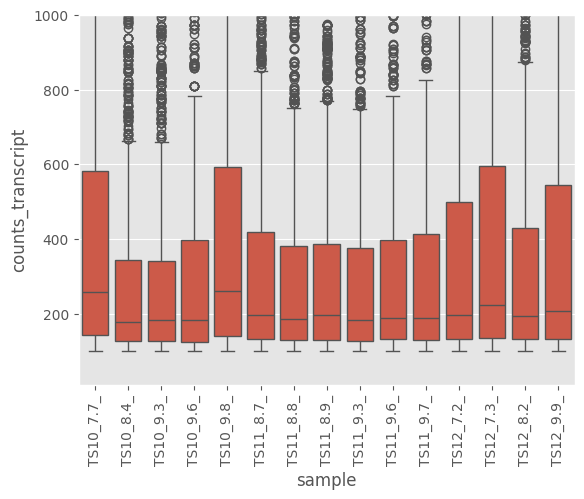

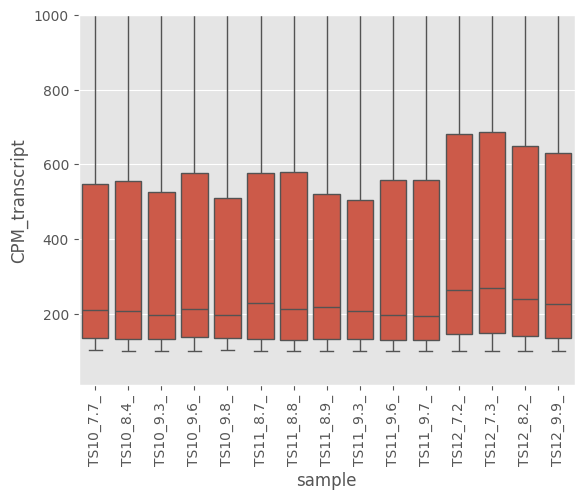

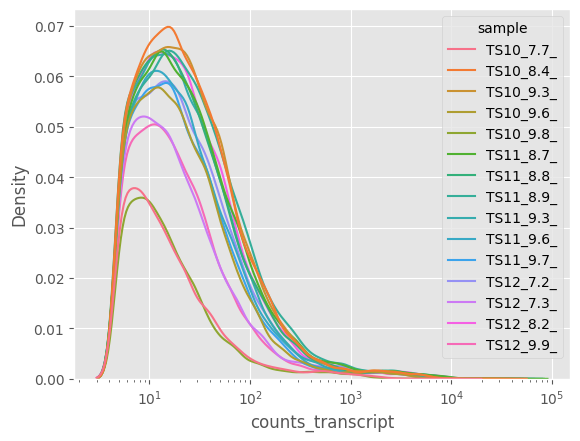

<function matplotlib.pyplot.show(close=None, block=None)>

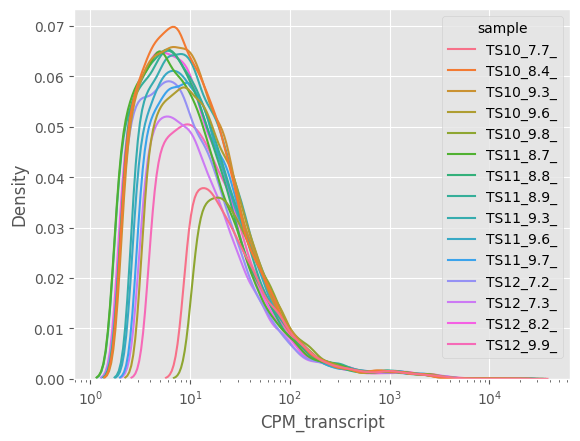

In [ ]:
sns.boxplot(mt[mt["counts_transcript"] >= 100], x="sample",y= "counts_transcript")
plt.xticks(rotation=90)
plt.ylim((10,1000))
plt.show()
sns.boxplot(mt[mt["CPM_transcript"] >= 100], x="sample",y= "CPM_transcript")
plt.xticks(rotation=90)
plt.ylim((10,1000))
plt.show()

sns.kdeplot(mt,x="counts_transcript",hue="sample",log_scale=True)

plt.show()
sns.kdeplot(mt,x="CPM_transcript",hue="sample",log_scale=True)

plt.show

In [ ]:

N=50
# Podemos sacar como una media del porcentaje de ISMs de los transcritos asociados al gen
mt["is_ISM"] = mt["structural_category"].eq("incomplete-splice_match")
gene_ism = (
    mt.groupby(["associated_gene", "TS", "RIN"], as_index=False)
      .apply(lambda g: pd.Series({
          "gene_ISM_perc": np.average(
              g["is_ISM"].astype(float),
              weights=g["counts"]
          ) * 100
      }))
)
mt = mt.merge(
    gene_ism,
    on=["associated_gene", "TS", "RIN"],
    how="left"
)
print(mt.columns)
#mt_fsm = mt[mt["structural_category"] == "full-splice_match"]
mt_fsm = mt[mt["CPM_transcript"]>=50]
mt_fsm["delta(diff_to_gene_TSS)"] == mt_fsm["delta(diff_to_gene_TSS)"]/mt_fsm["ref_length"]
# número total de subtablas
n_subtables = mt_fsm[['TS', 'RIN']].drop_duplicates().shape[0]

# cuántas subtablas distintas tiene cada gen
gene_counts = (
    mt_fsm.groupby('associated_gene')[['TS', 'RIN']]
      .apply(lambda x: x.drop_duplicates().shape[0])
)

# genes presentes en todas las subtablas
genes_validos = gene_counts[gene_counts == n_subtables].index

# filtrar la tabla original
mt_fsm = mt_fsm[mt_fsm['associated_gene'].isin(genes_validos)]
#Normalizamos las columnas con un z score 
#mt_fsm["delta(diff_to_gene_TSS)"] = (mt_fsm["delta(diff_to_gene_TSS)"] - mt_fsm["delta(diff_to_gene_TSS)"].mean()) / mt_fsm["delta(diff_to_gene_TSS)"].std()
#mt_fsm["ratio_counts"] = (mt_fsm["ratio_counts"] - mt_fsm["ratio_counts"].mean()) / mt_fsm["ratio_counts"].std()
# Sacamos las pendientes
pendientes_por_gen = (
    mt_fsm.groupby("associated_gene").apply(calc_pendiente, "gene_ISM_perc",include_groups=False)
)
# 3. Si quieres mapear estas pendientes de vuelta a tu "megatabla" original:
mt_fsm["pendiente"] = mt_fsm["associated_gene"].map(pendientes_por_gen)
# Sacamos la media del gen del ratio_counts
mt_fsm["mean_ratio"] = mt_fsm.groupby("associated_gene")["ratio_counts"].transform("mean")
mt_fsm["mean_diff"] = mt_fsm.groupby("associated_gene")["delta(diff_to_gene_TSS)"].transform("mean")

# Nos quitamos los monoexones
mt_fsm = mt_fsm[mt_fsm["ref_exons"] != 1]

# Quitamos filas duplicadas
mt_fsm = mt_fsm.drop_duplicates("associated_gene")

C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\3083134783.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


Index(['length', 'structural_category', 'associated_gene',
       'associated_transcript', 'ref_length', 'ref_exons', 'diff_to_gene_TSS',
       'diff_to_gene_TTS', 'strand', 'covered_exons', 'counts_transcript',
       'dip_test_TSS', 'dip_test_TSS_pval', 'counts', 'CV_diff_to_gene_TSS',
       'CV_diff_to_gene_TTS', 'TS', 'RIN', 'seqbatch', 'time',
       'exon_junction_density', 'porc_GC', 'CPM', 'CPM_transcript', 'clave',
       'ratio_counts', 'delta(diff_to_gene_TSS)', 'Cov_D1', 'Cov_D2', 'Cov_D3',
       'Cov_D4', 'Cov_D5', 'Cov_D6', 'Cov_D7', 'Cov_D8', 'Cov_D9', 'Cov_D10',
       'length_CDS', 'porc_GC_CDS', 'length_3pUTR', 'porc_GC_3pUTR',
       'length_5pUTR', 'porc_GC_5pUTR', 'is_ISM', 'gene_ISM_perc'],
      dtype='object')


In [ ]:
# Ordenamos por media de ratio_counts ; cuanto más "degradable" el gen, más bajo su ratio
mt_fsm = mt_fsm.sort_values(by="mean_ratio", ascending=True)

top_ratio = mt_fsm["associated_gene"].head(N).tolist()
low_ratio = mt_fsm["associated_gene"].tail(N).tolist()
mt_fsm["dif_median_ratio"] = abs(mt_fsm["mean_ratio"].median() - mt_fsm["mean_ratio"])
med_ratio = mt_fsm.sort_values(by="dif_median_ratio", ascending=True)["associated_gene"].head(N).tolist()

In [ ]:
# Ordenamos por media de diff
mt_fsm = mt_fsm.sort_values(by="mean_diff", ascending=False)

top_diff = mt_fsm["associated_gene"].head(N).tolist()
low_diff = mt_fsm["associated_gene"].tail(N).tolist()
mt_fsm["dif_median_diff"] = abs(mt_fsm["mean_diff"].median() - mt_fsm["mean_diff"])
med_diff = mt_fsm.sort_values(by="dif_median_diff", ascending=True)["associated_gene"].head(N).tolist()

In [ ]:
mt_fsm = mt_fsm.sort_values(by="pendiente",ascending = True)
top_pendiente = mt_fsm["associated_gene"].head(N).tolist()
low_pendiente = mt_fsm["associated_gene"].tail(N).tolist()
mt_fsm["dif_median_pendiente"] = abs(mt_fsm["mean_diff"].median() - mt_fsm["mean_diff"])
med_pendiente = mt_fsm.sort_values(by="dif_median_pendiente", ascending=True)["associated_gene"].head(N).tolist()

C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\602970149.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_["group"] = grupos[n]
C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\602970149.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_["group"] = grupos[n]
C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\602970149.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in t

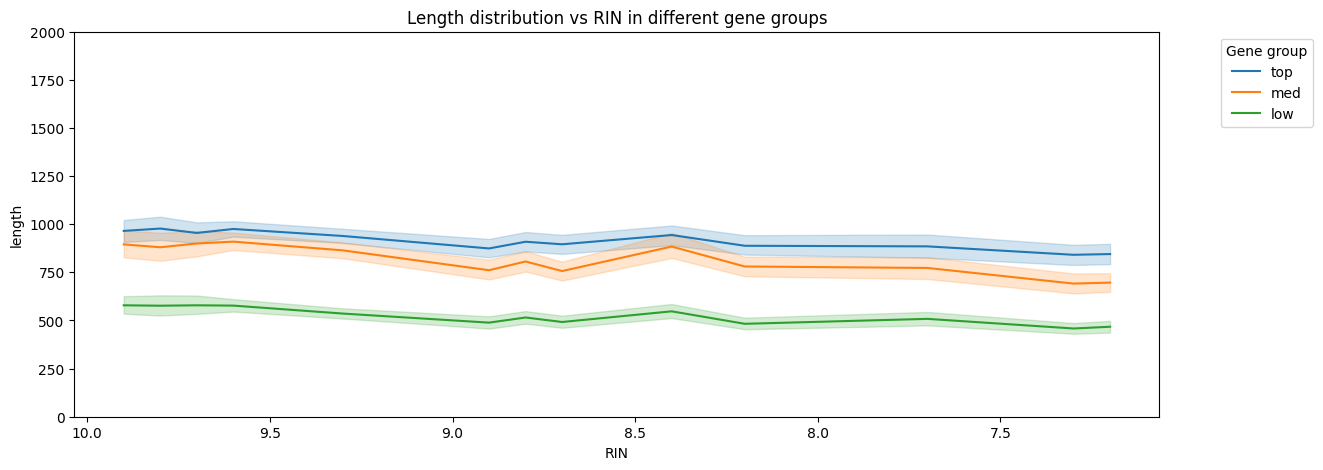

C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\602970149.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_["group"] = grupos[n]
C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\602970149.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_["group"] = grupos[n]
C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\602970149.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in t

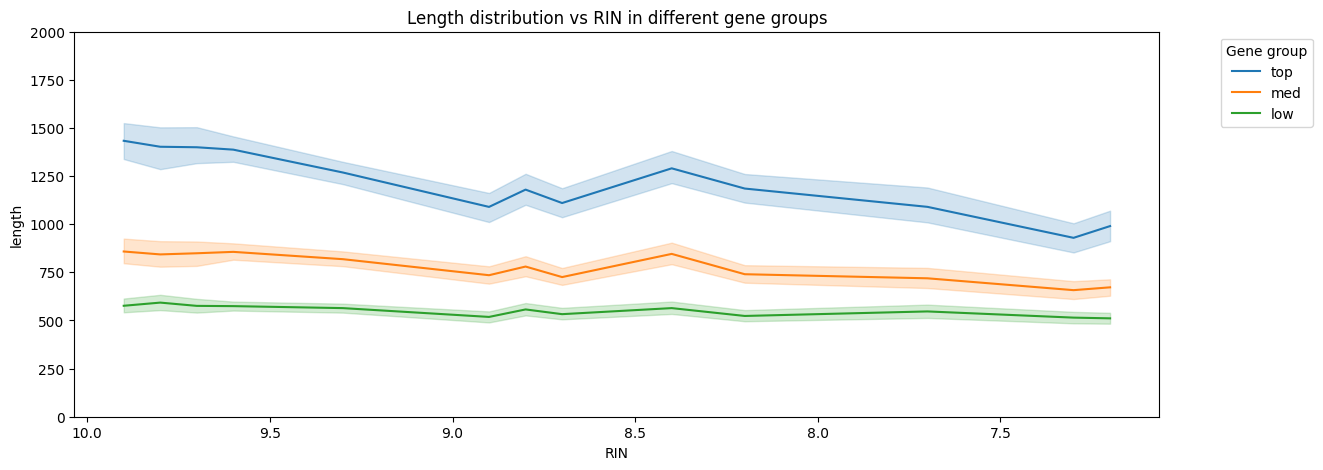

C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\602970149.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_["group"] = grupos[n]
C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\602970149.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_["group"] = grupos[n]
C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\602970149.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in t

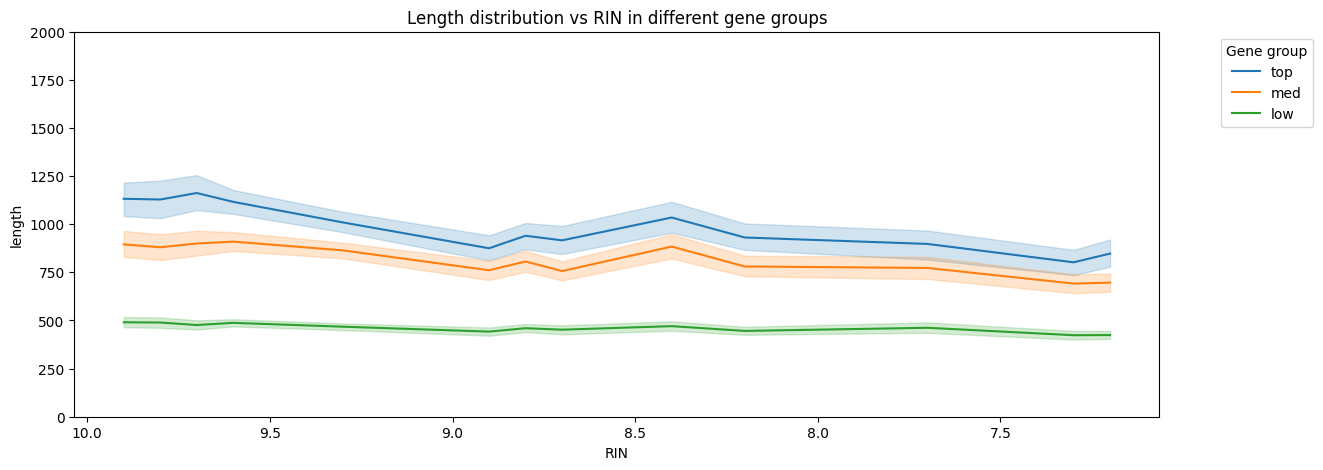

In [ ]:
grupos = ["top","med","low"]

for lista in [[top_pendiente,med_pendiente,low_pendiente], [top_ratio,med_ratio,low_ratio],[top_diff,med_diff,low_diff]]:
    dfs = []
    n = -1
    for i in lista:
        n += 1
        mt_ = mt[mt["associated_gene"].isin(i)]
        mt_["group"] = grupos[n]
        dfs.append(mt_)
    df_plot = pd.concat(dfs)
    plt.figure(figsize=(14, 5))
    sns.lineplot(df_plot,x="RIN",y="length",hue="group")
    plt.gca().invert_xaxis()
    plt.ylim(0,2000)
    plt.legend(title = "Gene group",bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title("Length distribution vs RIN in different gene groups")
    plt.show()


C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\1312769241.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_["group"] = grupos[n]
C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\1312769241.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_["group"] = grupos[n]
C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\1312769241.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

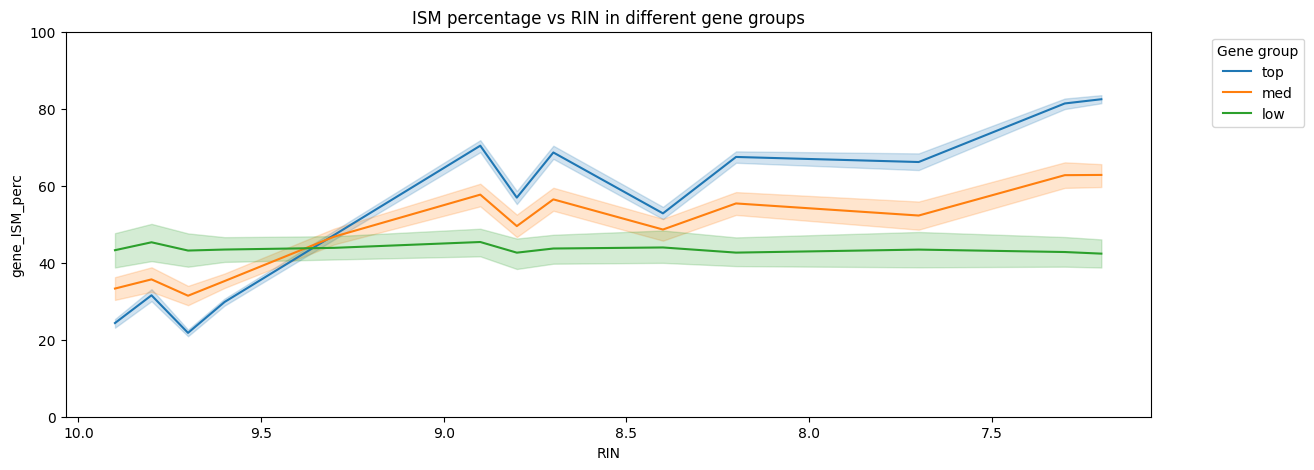

C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\1312769241.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_["group"] = grupos[n]
C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\1312769241.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_["group"] = grupos[n]
C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\1312769241.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

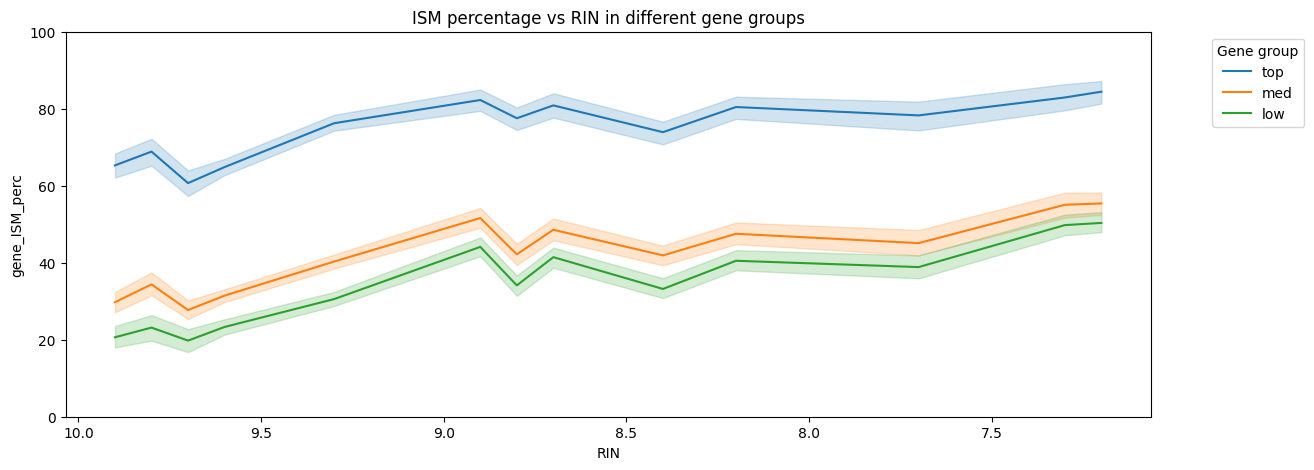

C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\1312769241.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_["group"] = grupos[n]
C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\1312769241.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_["group"] = grupos[n]
C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\1312769241.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

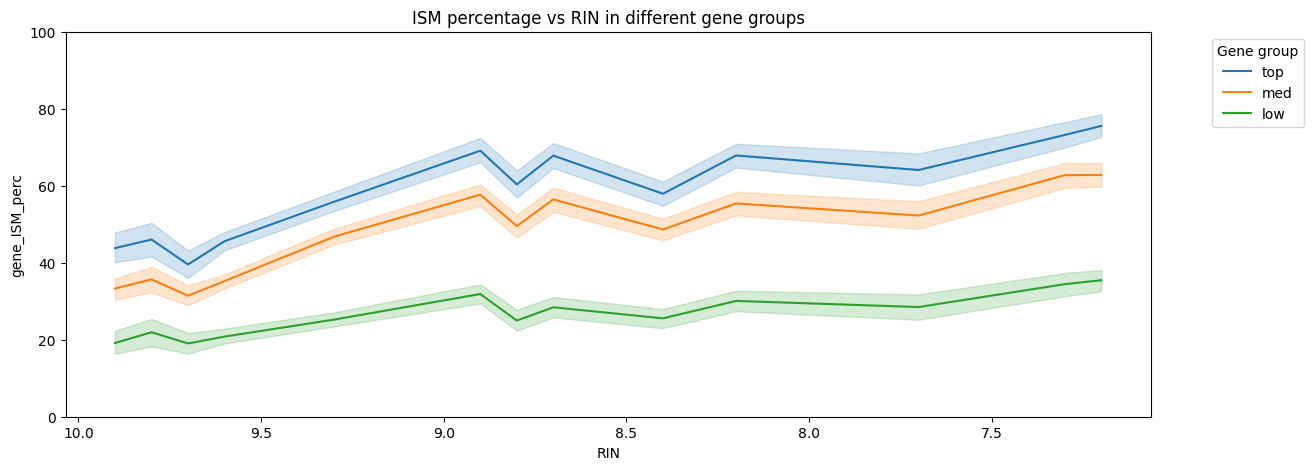

In [ ]:
grupos = ["top","med","low"]

for lista in [[top_pendiente,med_pendiente,low_pendiente], [top_ratio,med_ratio,low_ratio],[top_diff,med_diff,low_diff]]:
    dfs = []
    n = -1
    for i in lista:
        n += 1
        mt_ = mt[mt["associated_gene"].isin(i)]
        mt_["group"] = grupos[n]
        dfs.append(mt_)
    df_plot = pd.concat(dfs)
    plt.figure(figsize=(14, 5))
    sns.lineplot(df_plot,x="RIN",y="gene_ISM_perc",hue="group")
    plt.gca().invert_xaxis()
    plt.ylim(0,100)
    plt.legend(title = "Gene group",bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title("ISM percentage vs RIN in different gene groups")
    plt.show()

(43.5, 50.0)

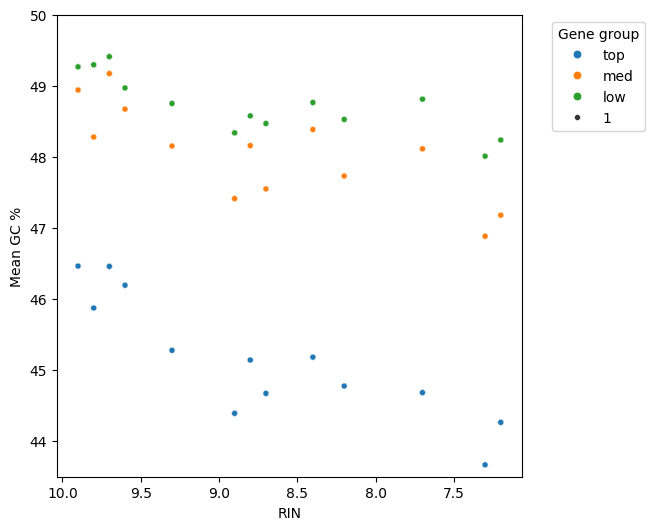

In [ ]:
df_plot["mean_GC_group"] = df_plot.groupby(["group","RIN"])["porc_GC"].transform("mean")
plt.figure(figsize=(6, 6))
sns.scatterplot(df_plot, x="RIN",y="mean_GC_group",hue="group",size=1)
plt.gca().invert_xaxis()
plt.ylabel("Mean GC %")
plt.legend(title = "Gene group",bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(43.5,50)

top
med
low


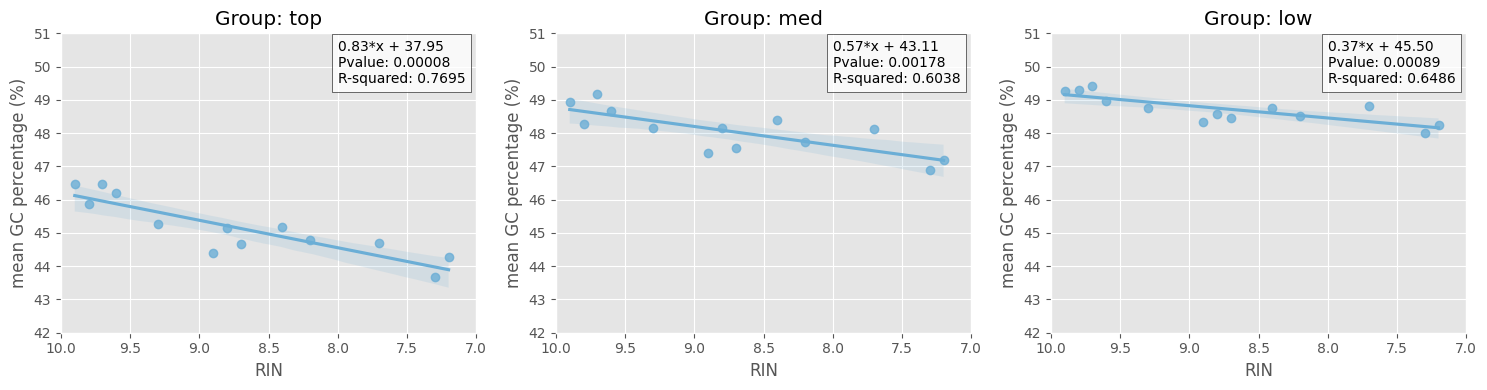

In [ ]:
ncols = 3
nrows = 1
plt.style.use("ggplot")
fig, axes = plt.subplots(nrows=nrows,
                            ncols=ncols,
                            figsize=(5*ncols,4*nrows)
                            )
axes = axes.flatten()

for ax,i in zip(axes,df_plot["group"].unique()):
    print(i)
    tabla_filt = df_plot[df_plot["group"] == i].drop_duplicates(["RIN","mean_GC_group"])
    lr = st.linregress(tabla_filt["RIN"],tabla_filt["mean_GC_group"])
    sns.regplot(data=tabla_filt,x = "RIN", y = "mean_GC_group",ax = ax,color="#6baed6")
    ax.invert_xaxis()
    ax.set_title(f"Group: {i}")
    
    ax.set_ylim(42,51)
    ax.set_xlim(10,7.0)
    ax.text(x = 8, y = 49.5, 
             s = f"{lr.slope:.2f}*x + {lr.intercept:.2f} \nPvalue: {lr.pvalue:.5f}\nR-squared: {lr.rvalue**2:.4f}",
             bbox=dict(facecolor='white', edgecolor='black', alpha=0.8))
    ax.set_ylabel("mean GC percentage (%)")
plt.tight_layout()
plt.show()

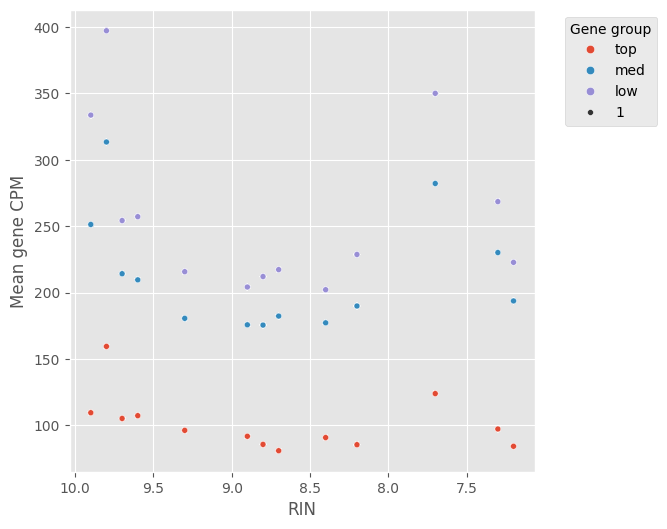

In [ ]:
df_plot["mean_gene_CPM"] = df_plot.groupby(["group","RIN"])["CPM"].transform("mean")
plt.figure(figsize=(6, 6))
sns.scatterplot(df_plot, x="RIN",y="mean_gene_CPM",hue="group",size=1)
plt.gca().invert_xaxis()
plt.ylabel("Mean gene CPM")
plt.legend(title = "Gene group",bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.ylim(43.5,50)

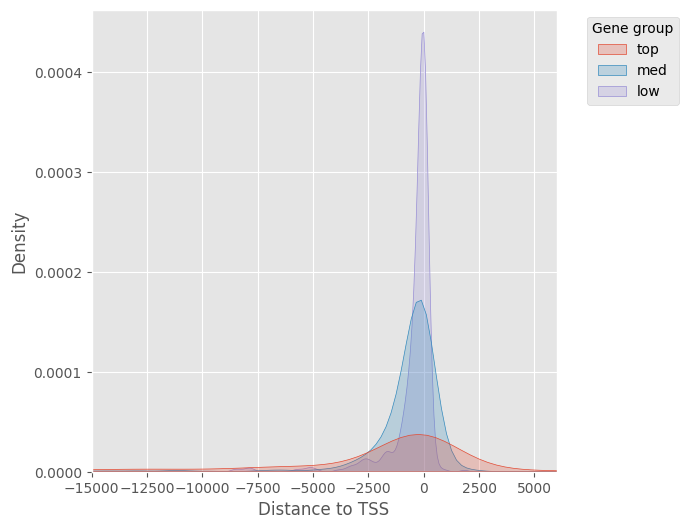

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tu línea de procesamiento (se mantiene igual)
df_plot["mean_gene_diff_to_TSS"] = df_plot.groupby(["group","RIN"])["diff_to_gene_TSS"].transform("mean")

plt.figure(figsize=(6, 6))

# 1. Guardamos el gráfico en la variable 'ax'
ax = sns.kdeplot(data=df_plot, x="diff_to_gene_TSS", hue="group", fill=True)

plt.xlim((-15000, 6000))
# Nota: Si estás pintando la distribución (KDE), el eje Y suele ser "Density". 
# Si quieres mantener tu título personalizado, déjalo así:
plt.ylabel("Density") 

# 2. Movemos la leyenda original de Seaborn modificando su posición y título
sns.move_legend(
    ax, 
    loc="upper left", 
    bbox_to_anchor=(1.05, 1), 
    title="Gene group"
)

plt.xlabel("Distance to TSS")
plt.show()

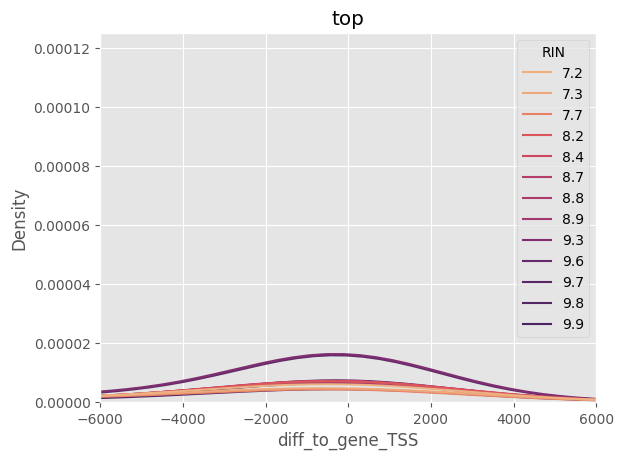

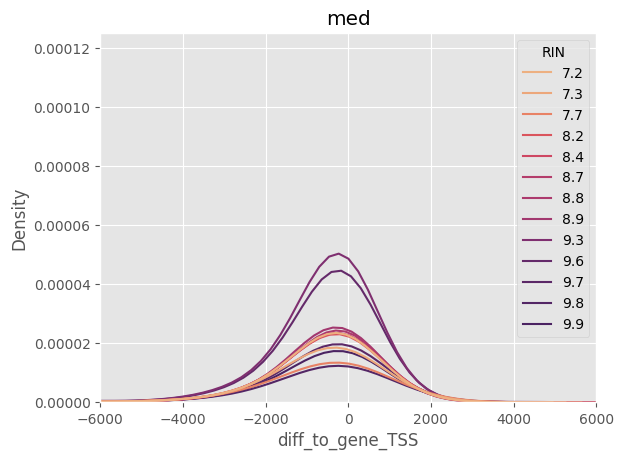

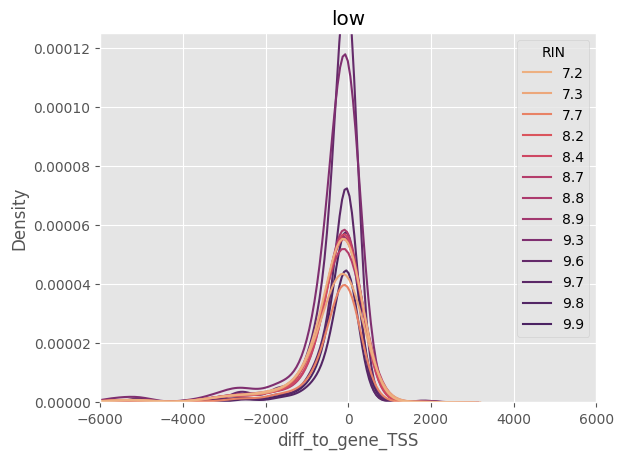

In [ ]:
for grupo in df_plot["group"].unique():
    sns.kdeplot(df_plot[df_plot["group"]== grupo],x="diff_to_gene_TSS", hue="RIN",palette="flare")
    plt.title(f"{grupo}")
    plt.xlim(-6000,6000)
    plt.ylim(0,0.000125)
    plt.show()

Index(['length', 'structural_category', 'associated_gene',
       'associated_transcript', 'ref_length', 'ref_exons', 'diff_to_gene_TSS',
       'diff_to_gene_TTS', 'strand', 'covered_exons', 'counts_transcript',
       'dip_test_TSS', 'dip_test_TSS_pval', 'counts', 'CV_diff_to_gene_TSS',
       'CV_diff_to_gene_TTS', 'TS', 'RIN', 'seqbatch', 'time',
       'exon_junction_density', 'porc_GC', 'CPM', 'CPM_transcript', 'clave',
       'ratio_counts', 'delta(diff_to_gene_TSS)', 'Cov_D1', 'Cov_D2', 'Cov_D3',
       'Cov_D4', 'Cov_D5', 'Cov_D6', 'Cov_D7', 'Cov_D8', 'Cov_D9', 'Cov_D10',
       'length_CDS', 'porc_GC_CDS', 'length_3pUTR', 'porc_GC_3pUTR',
       'length_5pUTR', 'porc_GC_5pUTR', 'is_ISM', 'gene_ISM_perc', 'group',
       'mean_GC_group', 'mean_gene_CPM', 'mean_gene_diff_to_TSS'],
      dtype='object')


Text(0.5, 1.0, 'Exon junction density by group')

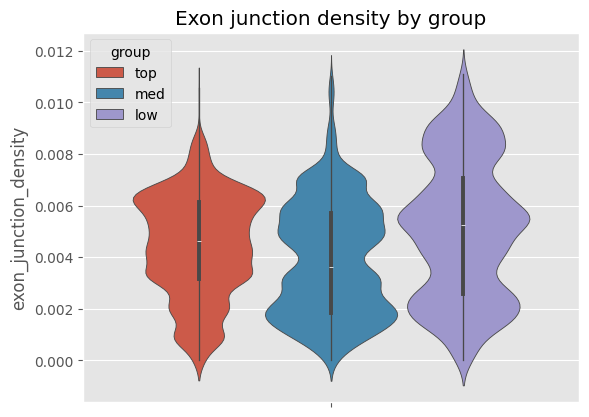

In [ ]:
print(df_plot.columns)
sns.violinplot(df_plot,y="exon_junction_density",hue="group")
plt.title("Exon junction density by group")


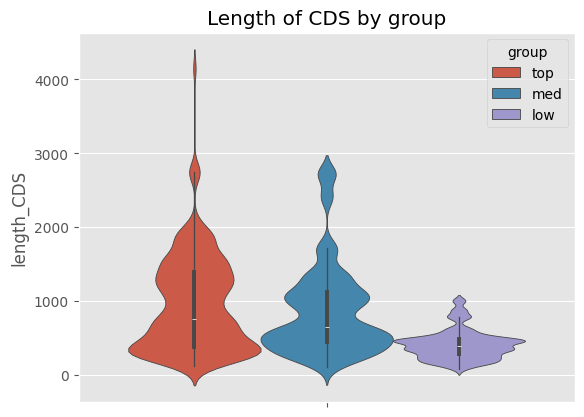

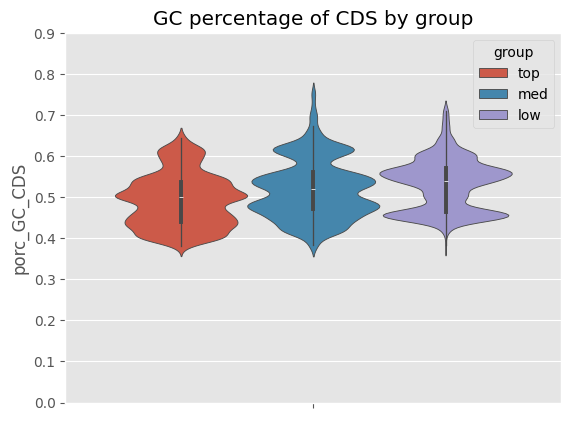

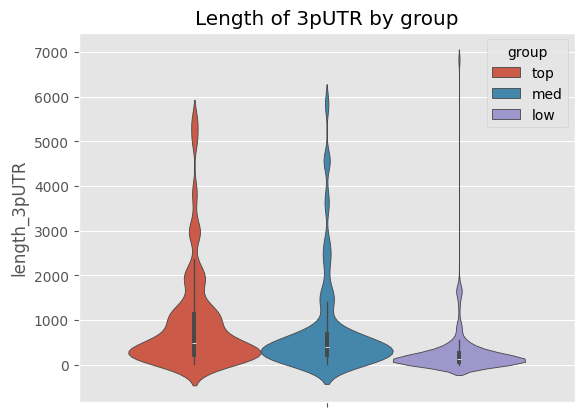

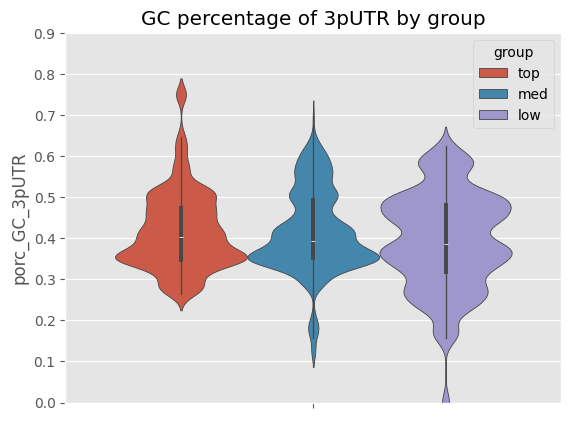

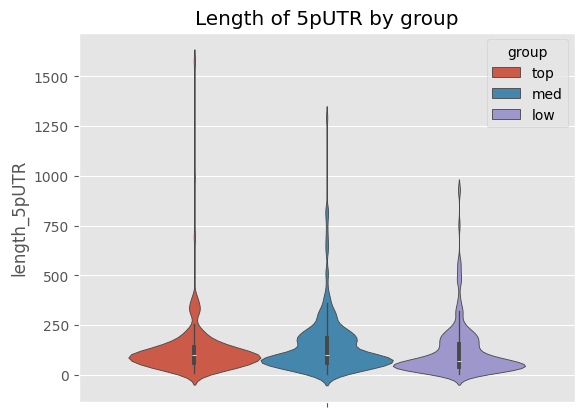

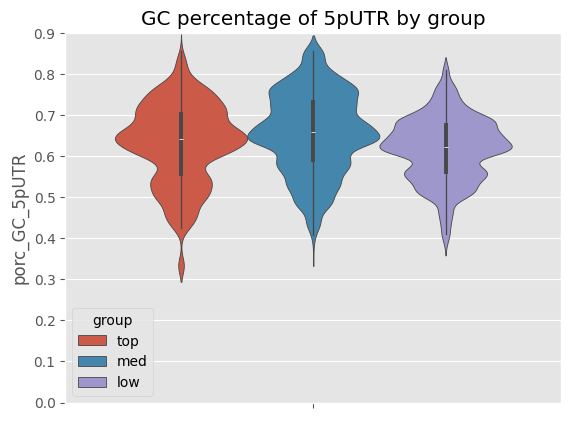

In [ ]:
df_plot = df_plot.reset_index(drop=True)
for i in ["CDS","3pUTR","5pUTR"]:
    sns.violinplot(df_plot,y=f"length_{i}",hue="group")
    plt.title(f"Length of {i} by group")
    plt.show()
    sns.violinplot(df_plot,y=f"porc_GC_{i}",hue="group")
    plt.title(f"GC percentage of {i} by group")
    plt.ylim(0,0.9)
    plt.show()

In [ ]:
cov_cols = [f'Cov_D{i}' for i in range(1, 11)]


def weighted_mean(series, counts):
    sum_counts = counts.loc[series.index].sum()
    if sum_counts == 0:
        return np.nan
    return np.sum(series * counts.loc[series.index]) / sum_counts

df_resumen = df_plot.groupby(['associated_gene', 'RIN', 'TS', 'group']).apply(
    lambda x: pd.Series({
        **{col: weighted_mean(x[col], x['counts']) for col in cov_cols},
        'counts': x['counts'].sum()
    })
).reset_index()
df_resumen.head()


C:\Users\Andres\AppData\Local\Temp\ipykernel_18408\655122885.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_resumen = df_plot.groupby(['associated_gene', 'RIN', 'TS', 'group']).apply(


,associated_gene,RIN,TS,group,Cov_D1,Cov_D2,Cov_D3,Cov_D4,Cov_D5,Cov_D6,Cov_D7,Cov_D8,Cov_D9,Cov_D10,counts
0,ENSG00000004059,7.2,TS12,med,0.000000,0.305965,0.311157,0.311157,0.560772,0.878834,0.881164,0.916407,0.941164,0.998719,208.0
1,ENSG00000004059,7.3,TS12,med,0.000000,0.244884,0.244884,0.244884,0.471486,1.000000,1.000000,1.000000,0.995335,0.998001,138.0
2,ENSG00000004059,7.7,TS10,med,0.000000,0.703936,0.720930,0.720930,0.776925,1.000000,1.000000,1.000000,0.998194,0.853692,75.0
3,ENSG00000004059,8.2,TS12,med,0.000000,0.531398,0.539960,0.539960,0.768400,0.985203,0.985203,1.000000,0.955276,0.958269,294.0
4,ENSG00000004059,8.4,TS10,med,0.002911,0.480256,0.483926,0.492988,0.705235,0.979625,0.988815,0.988815,0.970107,0.945033,340.0


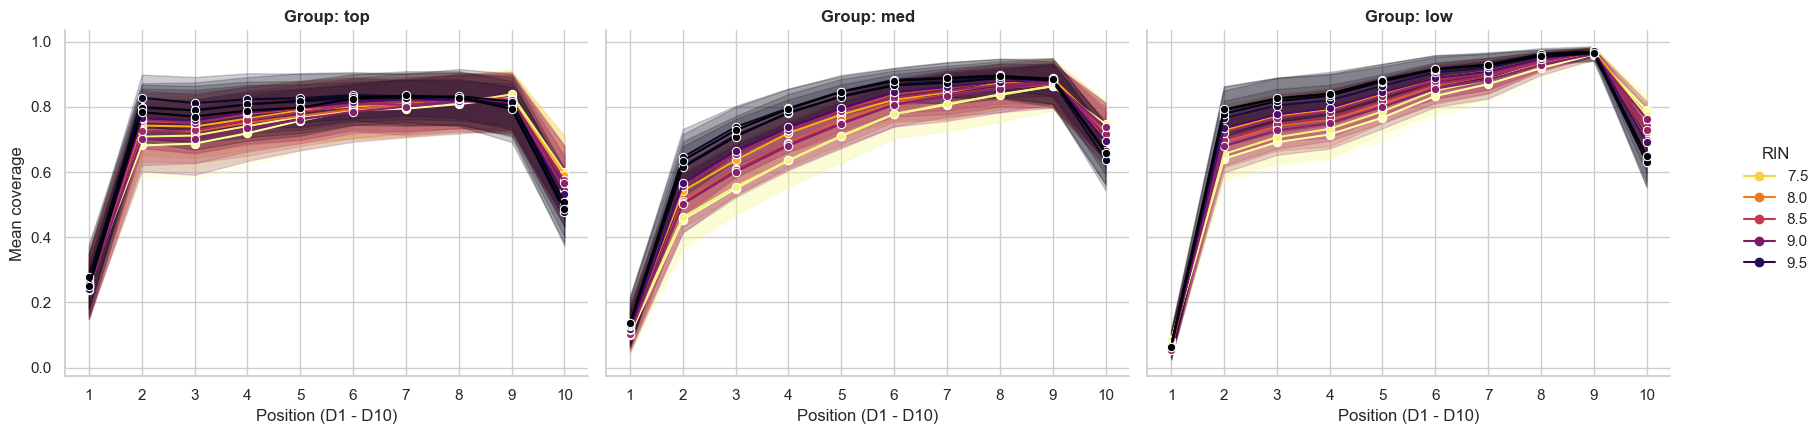

In [ ]:

df_long = df_resumen.melt(
    id_vars=['associated_gene', 'RIN', 'TS', 'group'],
    value_vars=[f'Cov_D{i}' for i in range(1, 11)],
    var_name='Position',
    value_name='Coverage'
)
df_long['Position'] = df_long['Position'].str.replace('Cov_D', '').astype(int)


sns.set_theme(style="whitegrid")

g = sns.relplot(
    data=df_long,
    x='Position',
    y='Coverage',
    hue='RIN',
    col='group',
    col_order=['top', 'med', 'low'], 
    kind='line',
    marker='o',
    height=4.5,
    aspect=1.2,
    palette='inferno_r',
)

g.set_axis_labels("Position (D1 - D10)", "Mean coverage")
g.set_titles("Group: {col_name}", weight='bold')
g.set(xticks=range(1, 11))
if g._legend:
    
    g._legend.set_bbox_to_anchor((1.02, 0.5))
    g._legend.set_loc('center left')

plt.subplots_adjust(right=0.88)
plt.tight_layout()
plt.show()